# RegMap — Fine-Tuned Semantic Retrieval for NIST 800-53 → HIPAA Mapping

Reproduces the RegMap paper's evaluation: fine-tuned Sentence-BERT vs. the off-the-shelf base encoder, BM25, and TF-IDF on the NIST↔HIPAA crosswalk test split. Computes Recall@k, MRR, and MAP with bootstrap 95% confidence intervals, under single-relevant and multi-relevant protocols.

**Prerequisites:** `data/processed/labeled_pairs.csv` (NIST↔HIPAA crosswalk) and the fine-tuned model in `models/regmap-embedder/`. Also downloads the base `all-MiniLM-L6-v2` from Hugging Face on first run.

In [1]:
# --- notebook path shim (makes the embedded evaluation script runnable in Jupyter) ---
from pathlib import Path


def _repo_root(p):
    for a in [p, *p.parents]:
        if (a / "data" / "processed").exists():
            return a
    return p


REPO = _repo_root(Path.cwd())
(REPO / "paper" / "regmap").mkdir(parents=True, exist_ok=True)
(REPO / "paper" / "regmap" / "figures").mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)


Repo root: C:\Users\User\ai-cybersecurity-portfolio


In [2]:
"""
Rigorous, paper-aware evaluation of the RegMap NIST 800-53 -> HIPAA retrieval
model, and baselines, on the crosswalk test split.

Task: given a NIST SP 800-53 control (query), retrieve the correct HIPAA
Security Rule provision(s) from a 60-provision corpus. Ground truth is the
official NIST<->HIPAA crosswalk.

Produces (into paper/regmap/):
  - results_regmap.json     machine-readable metrics with bootstrap 95% CIs
  - figures/recall_at_k.png Recall@k curves (fine-tuned vs base vs BM25 vs TF-IDF)
  - figures/metric_bars.png Recall@5 / MRR / MAP with CIs

Methods compared (identical test set, corpus, and relevance):
  - Fine-tuned Sentence-BERT (models/regmap-embedder) — ours
  - Off-the-shelf all-MiniLM-L6-v2 (the base model, no fine-tuning)
  - BM25 (lexical)
  - TF-IDF cosine (lexical)

Two relevance definitions are reported:
  - single-relevant per test pair (reproduces the original protocol)
  - multi-relevant per NIST control (all provisions the crosswalk maps to it)
"""
import ast
import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cos
from sklearn.model_selection import train_test_split


def _find_root(p):
    for a in [p, *p.parents]:
        if (a / "data" / "processed").exists():
            return a
    return p.parent


ROOT = REPO
DATA_PROC = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models" / "regmap-embedder"
BASE_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
HERE = REPO / "paper" / "regmap"
FIGS = HERE / "figures"; FIGS.mkdir(exist_ok=True)
RESULTS = HERE / "results_regmap.json"

SEED = 42
KS = [1, 3, 5, 10]
BOOT = 1000
rng = np.random.default_rng(SEED)


# ---------------- ranking backends -> per-query ranked corpus-index lists ----
def rank_dense(model, queries, corpus):
    cemb = model.encode(corpus, convert_to_tensor=True, show_progress_bar=False)
    orders = []
    for q in queries:
        qe = model.encode(q, convert_to_tensor=True, show_progress_bar=False)
        scores = torch.nn.functional.cosine_similarity(qe, cemb)
        orders.append(torch.argsort(scores, descending=True).tolist())
    return orders


def _tok(s):
    return re.findall(r"[a-z0-9]+", s.lower())


def rank_bm25(queries, corpus):
    bm = BM25Okapi([_tok(c) for c in corpus])
    return [list(np.argsort(bm.get_scores(_tok(q)))[::-1]) for q in queries]


def rank_tfidf(queries, corpus):
    vec = TfidfVectorizer().fit(corpus + queries)
    C = vec.transform(corpus)
    orders = []
    for q in queries:
        sims = sk_cos(vec.transform([q]), C)[0]
        orders.append(list(np.argsort(sims)[::-1]))
    return orders


# ---------------- metrics ----------------
def per_query_metrics(order, relevant_ids, ks):
    """order: ranked corpus indices; relevant_ids: set. Returns dict of hit@k,
    recall@k, reciprocal rank, average precision."""
    rel = set(relevant_ids)
    out = {}
    for k in ks:
        topk = order[:k]
        out[f"hit@{k}"] = 1.0 if rel & set(topk) else 0.0
        out[f"recall@{k}"] = len(rel & set(topk)) / len(rel)
    # reciprocal rank of first relevant
    rr = 0.0
    for i, idx in enumerate(order, 1):
        if idx in rel:
            rr = 1.0 / i
            break
    out["rr"] = rr
    # average precision
    hits = 0; ap = 0.0
    for i, idx in enumerate(order, 1):
        if idx in rel:
            hits += 1
            ap += hits / i
    out["ap"] = ap / len(rel) if rel else 0.0
    return out


def aggregate(per_q, ks):
    """Mean each metric + bootstrap 95% CI over queries."""
    keys = [f"hit@{k}" for k in ks] + [f"recall@{k}" for k in ks] + ["rr", "ap"]
    arr = {key: np.array([m[key] for m in per_q]) for key in keys}
    n = len(per_q)
    res = {}
    for key, vals in arr.items():
        boot = np.array([vals[rng.integers(0, n, n)].mean() for _ in range(BOOT)])
        res[key] = {"mean": float(vals.mean()),
                    "ci_lo": float(np.percentile(boot, 2.5)),
                    "ci_hi": float(np.percentile(boot, 97.5))}
    return res


def evaluate(orders, relevant_per_query, ks):
    per_q = [per_query_metrics(o, rel, ks) for o, rel in zip(orders, relevant_per_query)]
    return aggregate(per_q, ks)


def main():
    cw = pd.read_csv(DATA_PROC / "labeled_pairs.csv").dropna(subset=["nist_text", "hipaa_text"])
    train_val, test = train_test_split(cw, test_size=0.15, random_state=SEED)
    corpus = list(cw["hipaa_text"].unique())
    cidx = {t: i for i, t in enumerate(corpus)}

    # control -> all relevant provision indices (multi-relevant ground truth)
    control_rel = defaultdict(set)
    for _, r in cw.iterrows():
        control_rel[r["nist_control_id"]].add(cidx[r["hipaa_text"]])

    # --- protocol A: per-pair, single-relevant (reproduces original) ---
    q_texts = test["nist_text"].tolist()
    rel_single = [{cidx[t]} for t in test["hipaa_text"].tolist()]
    # --- protocol B: multi-relevant per control ---
    rel_multi = [control_rel[cid] for cid in test["nist_control_id"].tolist()]

    models = {
        "fine_tuned": SentenceTransformer(str(MODEL_DIR)),
        "base_minilm": SentenceTransformer(BASE_MODEL),
    }
    orders = {}
    for name, m in models.items():
        orders[name] = rank_dense(m, q_texts, corpus)
    orders["bm25"] = rank_bm25(q_texts, corpus)
    orders["tfidf"] = rank_tfidf(q_texts, corpus)

    results = {"config": {"test_queries": len(q_texts), "corpus": len(corpus),
                          "seed": SEED, "bootstrap": BOOT},
               "single_relevant": {}, "multi_relevant": {}}
    for name, o in orders.items():
        results["single_relevant"][name] = evaluate(o, rel_single, KS)
        results["multi_relevant"][name] = evaluate(o, rel_multi, KS)
    RESULTS.write_text(json.dumps(results, indent=2))

    # ---- figures (single-relevant protocol, matching the original) ----
    labels = {"fine_tuned": "Fine-tuned SBERT (ours)", "base_minilm": "Base all-MiniLM-L6-v2",
              "bm25": "BM25", "tfidf": "TF-IDF"}
    plt.figure(figsize=(5.5, 4))
    for name in orders:
        ys = [results["single_relevant"][name][f"recall@{k}"]["mean"] for k in KS]
        plt.plot(KS, ys, marker="o", label=labels[name])
    plt.xlabel("k"); plt.ylabel("Recall@k"); plt.title("NIST→HIPAA retrieval — Recall@k")
    plt.xticks(KS); plt.ylim(0, 1); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(FIGS / "recall_at_k.png", dpi=200); plt.close()

    plt.figure(figsize=(6, 4))
    metrics = [("recall@5", "Recall@5"), ("rr", "MRR"), ("ap", "MAP")]
    x = np.arange(len(metrics)); w = 0.2
    for j, name in enumerate(orders):
        means = [results["single_relevant"][name][mk]["mean"] for mk, _ in metrics]
        los = [results["single_relevant"][name][mk]["mean"] - results["single_relevant"][name][mk]["ci_lo"] for mk, _ in metrics]
        his = [results["single_relevant"][name][mk]["ci_hi"] - results["single_relevant"][name][mk]["mean"] for mk, _ in metrics]
        plt.bar(x + j * w, means, w, yerr=[los, his], capsize=3, label=labels[name])
    plt.xticks(x + 1.5 * w, [lbl for _, lbl in metrics]); plt.ylim(0, 1)
    plt.ylabel("score"); plt.title("Retrieval quality with 95% CIs"); plt.legend(); plt.tight_layout()
    plt.savefig(FIGS / "metric_bars.png", dpi=200); plt.close()

    print("==== RegMap eval (single-relevant protocol) ====")
    print(f"{'method':>22} {'R@1':>6} {'R@3':>6} {'R@5':>6} {'R@10':>6} {'MRR':>6} {'MAP':>6}")
    for name in orders:
        r = results["single_relevant"][name]
        print(f"{labels[name]:>22} "
              f"{r['recall@1']['mean']:>6.3f} {r['recall@3']['mean']:>6.3f} "
              f"{r['recall@5']['mean']:>6.3f} {r['recall@10']['mean']:>6.3f} "
              f"{r['rr']['mean']:>6.3f} {r['ap']['mean']:>6.3f}")
    print(f"results -> {RESULTS}\nfigures -> {FIGS}")


main()


C:\Users\User\ai-cybersecurity-portfolio\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5993.19it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6984.52it/s]

==== RegMap eval (single-relevant protocol) ====
                method    R@1    R@3    R@5   R@10    MRR    MAP
Fine-tuned SBERT (ours)  0.265  0.559  0.735  0.824  0.463  0.463
 Base all-MiniLM-L6-v2  0.235  0.353  0.500  0.706  0.367  0.367
                  BM25  0.088  0.294  0.353  0.471  0.233  0.233
                TF-IDF  0.265  0.382  0.500  0.618  0.364  0.364
results -> C:\Users\User\ai-cybersecurity-portfolio\paper\regmap\results_regmap.json
figures -> C:\Users\User\ai-cybersecurity-portfolio\paper\regmap\figures


metric_bars.png


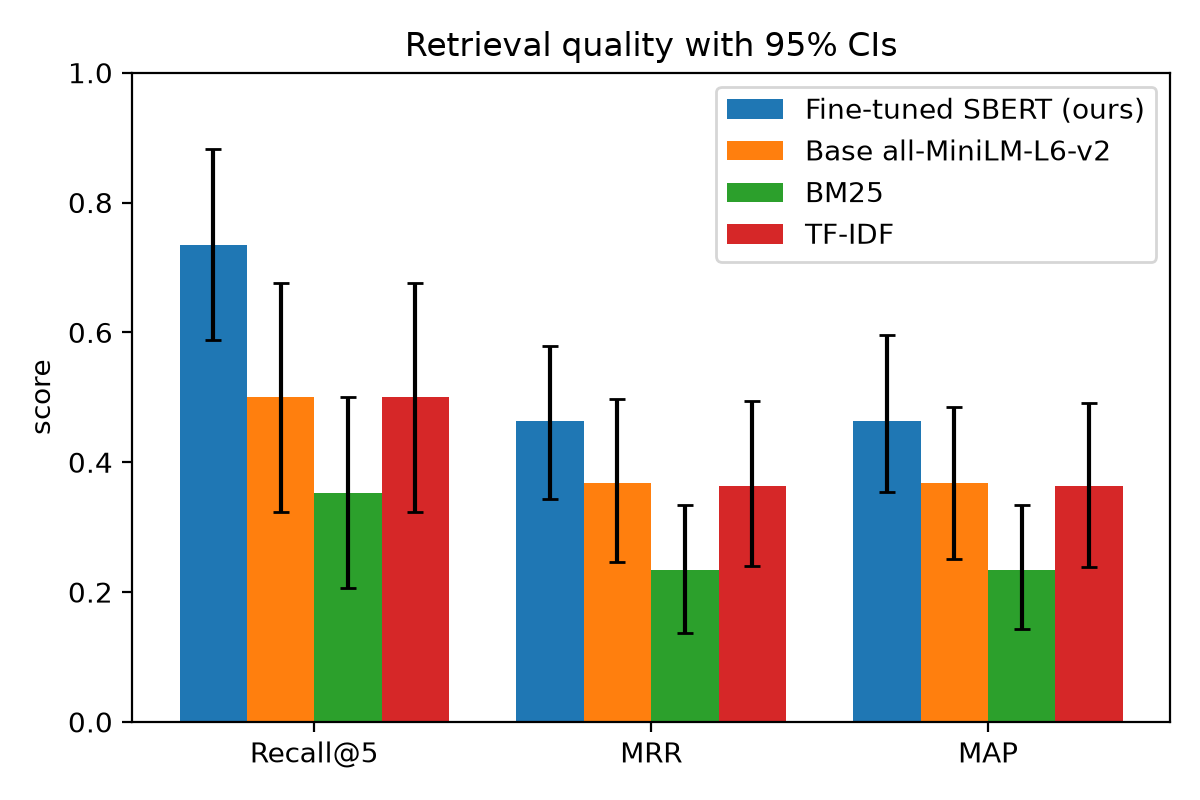

recall_at_k.png


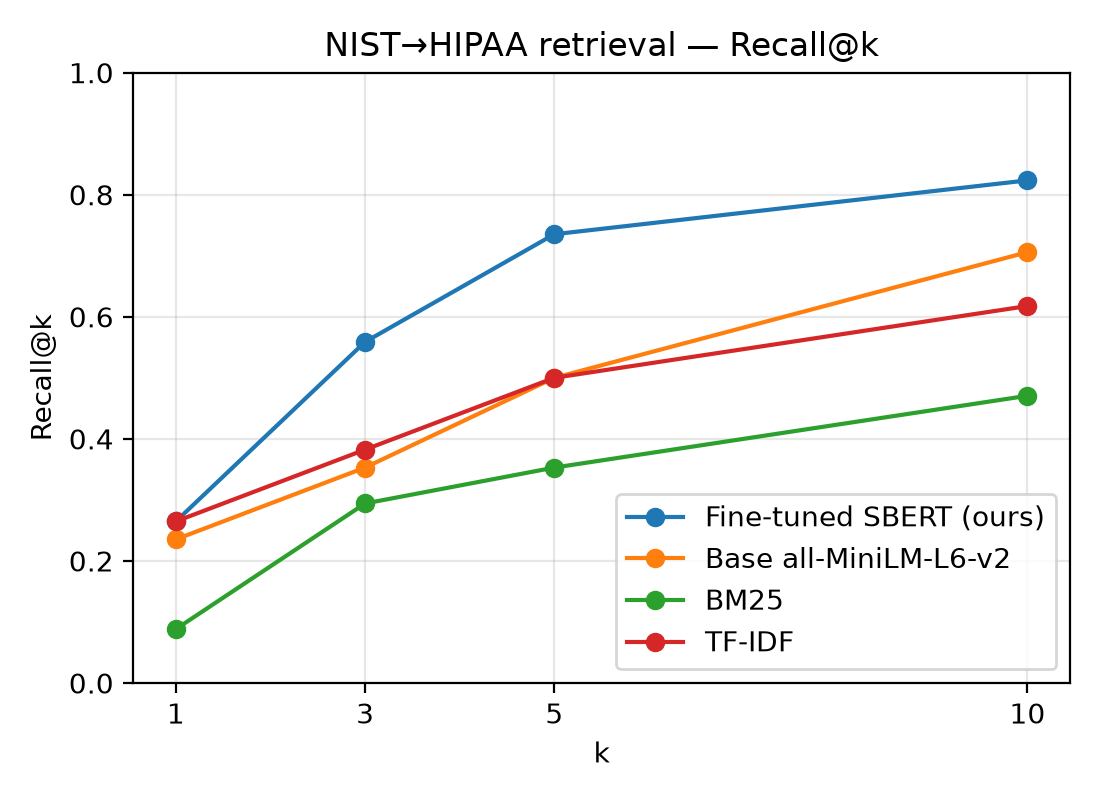

In [3]:
# --- display the result figures inline ---
import os
from IPython.display import Image, display

_figdir = REPO / "paper" / "regmap" / "figures"
for _f in sorted(os.listdir(_figdir)):
    if _f.endswith(".png") and not _f.startswith("eq_"):
        print(_f)
        display(Image(str(_figdir / _f)))
